In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#### **Listed and Sold Properties**

In [2]:
df_listing = pd.read_csv("../data/Listing/listed_transactions.csv", encoding="ISO-8859-1")

C:\Users\mayab\AppData\Local\Temp\ipykernel_4104\2095627017.py:1: DtypeWarning: Columns (0: ListAgentEmail, 1: BuyerAgencyCompensationType) have mixed types. Specify dtype option on import or set low_memory=False.
  df_listing = pd.read_csv("../data/Listing/listed_transactions.csv", encoding="ISO-8859-1")


In [3]:
df_sold = pd.read_csv("../data/Sold/sold_transactions.csv", encoding="ISO-8859-1")

C:\Users\mayab\AppData\Local\Temp\ipykernel_4104\3090260199.py:1: DtypeWarning: Columns (0: BuyerAgentAOR, 1: ListAgentAOR, 2: WaterfrontYN, 3: ListAgentEmail, 4: OriginatingSystemName, 5: OriginatingSystemSubName, 6: BuyerAgencyCompensationType, 7: latfilled, 8: lonfilled) have mixed types. Specify dtype option on import or set low_memory=False.
  df_sold = pd.read_csv("../data/Sold/sold_transactions.csv", encoding="ISO-8859-1")


In [4]:
# What are shared
set(df_listing.columns).intersection(set(df_sold.columns))

{'AboveGradeFinishedArea',
 'AssociationFee',
 'AssociationFeeFrequency',
 'AttachedGarageYN',
 'BathroomsTotalInteger',
 'BedroomsTotal',
 'BelowGradeFinishedArea',
 'BuilderName',
 'BuildingAreaTotal',
 'BusinessType',
 'BuyerAgencyCompensation',
 'BuyerAgencyCompensationType',
 'BuyerAgentFirstName',
 'BuyerAgentLastName',
 'BuyerAgentMlsId',
 'BuyerOfficeAOR',
 'BuyerOfficeName',
 'City',
 'CloseDate',
 'ClosePrice',
 'CoBuyerAgentFirstName',
 'CoListAgentFirstName',
 'CoListAgentLastName',
 'CoListOfficeName',
 'ContractStatusChangeDate',
 'CountyOrParish',
 'CoveredSpaces',
 'DaysOnMarket',
 'ElementarySchool',
 'ElementarySchoolDistrict',
 'FireplaceYN',
 'FireplacesTotal',
 'GarageSpaces',
 'HighSchool',
 'HighSchoolDistrict',
 'Latitude',
 'Levels',
 'ListAgentEmail',
 'ListAgentFirstName',
 'ListAgentFullName',
 'ListAgentLastName',
 'ListOfficeName',
 'ListPrice',
 'ListingContractDate',
 'ListingId',
 'ListingKey',
 'ListingKeyNumeric',
 'LivingArea',
 'Longitude',
 'LotSiz

In [5]:
# What are not shared 
set(df_listing.columns).difference(set(df_sold.columns))

{'BuyerOfficeName.1',
 'CloseDate.1',
 'DaysOnMarket.1',
 'Latitude.1',
 'ListAgentFirstName.1',
 'ListAgentLastName.1',
 'ListPrice.1',
 'LivingArea.1',
 'Longitude.1',
 'PropertyType.1',
 'UnparsedAddress.1'}

In [6]:
shared_builder = df_listing[df_listing['BuilderName'].isin(df_sold['BuilderName'])]['BuilderName'].nunique()
shared_builder

3559

In [7]:
print(df_listing[df_listing['BuilderName'].isin(df_sold['BuilderName'])]['BuilderName'].value_counts())

BuilderName
Lennar                                2568
Toll Brothers                         1357
Meritage Homes                         924
Shea Homes                             751
D.R. Horton                            739
                                      ... 
Quartaroli                               1
Brookvale                                1
William Lyon Homes/Taylor Morrison       1
Henry Hill                               1
New Cities                               1
Name: count, Length: 3559, dtype: int64


In [8]:
listed_cities = df_listing[df_listing.BuilderName == "Lennar"].City.unique()
sold_cities = df_sold[df_sold.BuilderName == "Lennar"].City.unique()

In [9]:
print(listed_cities)

<StringArray>
[                'Irvine',                 'Corona',               'Valencia',
            'Lake Forest',              'Escondido',         'San Bernardino',
            'Palm Desert',               'Eastvale',                'Anaheim',
              'La Quinta',           'Indian Wells',   'Rancho Mission Viejo',
                'Fontana',                 'Tustin',                  'Indio',
               'Redlands',            'Simi Valley',            'Santa Paula',
                  'Hemet',               'Calimesa',       'Huntington Beach',
              'San Ramon',                 'Dublin',             'Montebello',
               'Torrance',          'Jurupa Valley',              'Livermore',
    'San Juan Capistrano',                'Fremont',            'West Covina',
                  'Chino',                  'Tracy',               'Danville',
               'Murrieta',                 'Upland',            'Yorba Linda',
              'Oceanside',            

In [10]:
print(sold_cities)

<StringArray>
[                'Irvine',            'Lake Forest',                 'Clovis',
                'Ontario',                'Arcadia',            'Yorba Linda',
                  'Chino',                  'Indio',              'Santa Ana',
   'Rancho Mission Viejo',             'Winchester',               'Torrance',
               'Eastvale',        'Fountain Valley',                'Fontana',
               'Danville',            'Santa Paula',              'La Quinta',
            'West Covina',       'Huntington Beach',                 'Saugus',
             'Montebello',                  'Hemet',              'Escondido',
            'Palm Desert',              'San Ramon',           'Indian Wells',
                 'Tustin',               'Calimesa',         'San Bernardino',
    'San Juan Capistrano',                 'Dublin',                 'Rialto',
                'Anaheim',               'Valencia',        'El Dorado Hills',
                 'Upland',            

In [11]:
lennar_listing = df_listing[df_listing['BuilderName'] == 'Lennar']
lennar_listing.head()

,OriginalListPrice,ListingKey,ListAgentEmail,CloseDate,ClosePrice,ListAgentFirstName,ListAgentLastName,Latitude,Longitude,UnparsedAddress,...,NewConstructionYN,GarageSpaces,HighSchoolDistrict,PostalCode,BuyerOfficeName.1,AssociationFee,LotSizeSquareFeet,MiddleOrJuniorSchoolDistrict,UnparsedAddress.1,Year
424,6000.0,1061938406,linda.laplante@cbrealty.com,2024-03-08,6000.0,Linda,LaPlante,33.693940,-117.757061,29 Sanctuary,...,False,2.0,Irvine Unified,92620,Coldwell Banker Realty,NaN,4950.00,NaN,29 Sanctuary,2024
434,1039000.0,1061932488,Mark.M.Adams@exprealty.com,2024-03-25,1039000.0,Mark,Adams,33.814139,-117.538056,1735 Spyglass Drive,...,False,3.0,Corona-Norco Unified,92883,Compass,72.0,9583.00,NaN,1735 Spyglass Drive,2024
585,1790000.0,1061576831,kimberly@terrafrancarealty.com,2024-03-21,1790000.0,Kimberly,Terrafranca,33.682878,-117.725220,165 Scale,...,False,2.0,Irvine Unified,92618,The Oppenheim Group,235.0,NaN,NaN,165 Scale,2024
1289,5700.0,1060063308,amilieyangla@gmail.com,2024-04-30,5400.0,YUQIAN,YANG,34.420267,-118.612215,27528 GOLDEN CURRANT Place,...,False,2.0,William S. Hart Union,91381,HARVEST REALTY DEVELOPMENT,NaN,27110.00,NaN,27528 GOLDEN CURRANT Place,2024
3029,1049000.0,1059580878,dick@cooperonefourteen.com,2024-03-22,1029000.0,Dick,Hamparsumian,33.673930,-117.847552,3208 Rivington,...,True,1.0,Santa Ana Unified,92612,Pinnacle Real Estate Group,813.0,68737.68,NaN,3208 Rivington,2024


In [12]:
lennar_listing['OriginalListPrice'].describe()

count    2.568000e+03
mean     9.195411e+05
std      7.186886e+05
min      1.100000e+03
25%      5.649575e+05
50%      7.499000e+05
75%      1.146000e+06
max      1.559999e+07
Name: OriginalListPrice, dtype: float64

In [13]:
toll_brothers_listing = df_listing[df_listing['BuilderName'] == 'Toll Brothers']
toll_brothers_listing.head()

,OriginalListPrice,ListingKey,ListAgentEmail,CloseDate,ClosePrice,ListAgentFirstName,ListAgentLastName,Latitude,Longitude,UnparsedAddress,...,NewConstructionYN,GarageSpaces,HighSchoolDistrict,PostalCode,BuyerOfficeName.1,AssociationFee,LotSizeSquareFeet,MiddleOrJuniorSchoolDistrict,UnparsedAddress.1,Year
43,18000.0,1072379815,homes@bobandanneclaydon.com,NaN,NaN,Anne,Claydon,33.682522,-116.257933,50520 Los Verdes Way,...,False,3.0,NaN,92253,NaN,510.0,9148.0,NaN,50520 Los Verdes Way,2024
2134,2904995.0,1059617983,lhalla@tollbrothers.com,NaN,NaN,Laura,Halla,NaN,NaN,18402 Corte Borremeo,...,False,3.0,Morgan Hill Unified,95037,Datashare SFAR Default Office Don't Delete,367.0,12141.0,NaN,18402 Corte Borremeo,2024
2136,2999995.0,1059617980,lhalla@tollbrothers.com,NaN,NaN,Laura,Halla,NaN,NaN,18372 Corte Borremo,...,False,3.0,Morgan Hill Unified,95037,Montalvo Realty,367.0,12119.0,NaN,18372 Corte Borremo,2024
2138,2884995.0,1059617977,lhalla@tollbrothers.com,NaN,NaN,Laura,Halla,NaN,NaN,18382 Corte Borremeo,...,False,3.0,Morgan Hill Unified,95037,Berkshire Hathaway HomeService,367.0,10000.0,NaN,18382 Corte Borremeo,2024
2193,2895000.0,1059616686,drew@thehd.team,2024-04-15,2775000.0,Andrew,RebulioD'Angelo,33.666609,-117.666484,201 Royal,...,True,2.0,Saddleback Valley Unified,92630,Coldwell Banker Realty,290.0,4900.0,NaN,201 Royal,2024


In [14]:
toll_brothers_listing['OriginalListPrice'].describe()

count    1.357000e+03
mean     1.616358e+06
std      1.138264e+06
min      2.900000e+03
25%      8.890000e+05
50%      1.463995e+06
75%      2.099000e+06
max      1.103900e+07
Name: OriginalListPrice, dtype: float64

In [15]:
shared_agent = df_listing[df_listing['ListAgentEmail'].isin(df_sold['ListAgentEmail'])]['ListAgentEmail'].nunique()
shared_agent

88424

In [16]:
print(df_listing[df_listing['ListAgentEmail'].isin(df_sold['ListAgentEmail'])]['ListAgentEmail'].value_counts())

ListAgentEmail
info@nikolaleasing.com                      2146
info@homecoin.com                           1118
randy.anderson@richmondamericanhomes.com    1091
homes@opendoor.com                          1022
shahin@wisemanresidential.com                954
                                            ... 
Kirkland4re@gmail.com                          1
dharmbirs@gmail.com                            1
vantha.realbrokerage@gmail.com                 1
valerie@myhousingwizard.com                    1
karen.silvas@compass.com                       1
Name: count, Length: 88424, dtype: int64


#### Numeric Distribution Review

##### *Listing*

Analyze the dstribution of the following key numeric fileds; for each field, generate histograms, boxplots, and percentile summaries, and identify extreme outliers for later handling

In [17]:
cols = ['ClosePrice', 'ListPrice', 'OriginalListPrice', 'LivingArea', 'LotSizeAcres', 'BedroomsTotal', 'BathroomsTotalInteger', 'DaysOnMarket', 'YearBuilt']

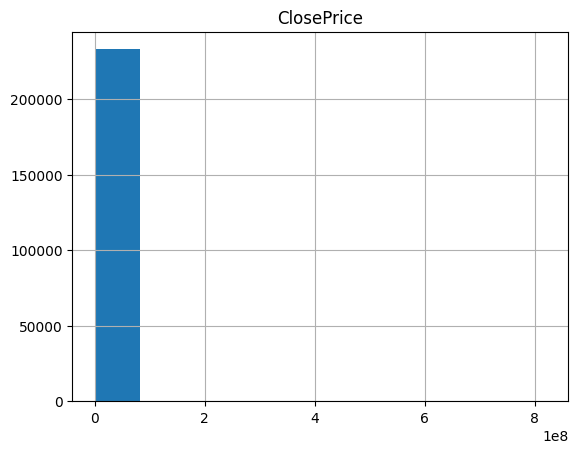

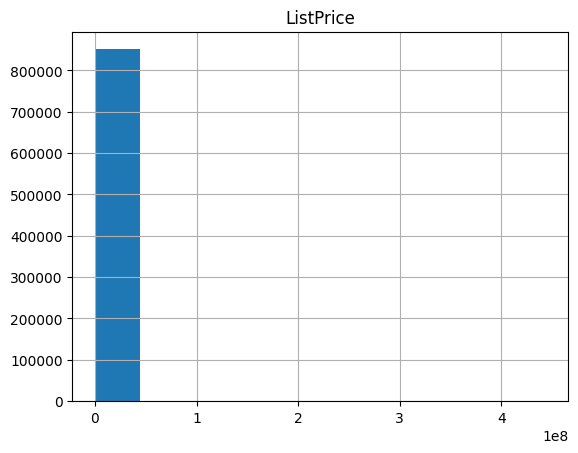

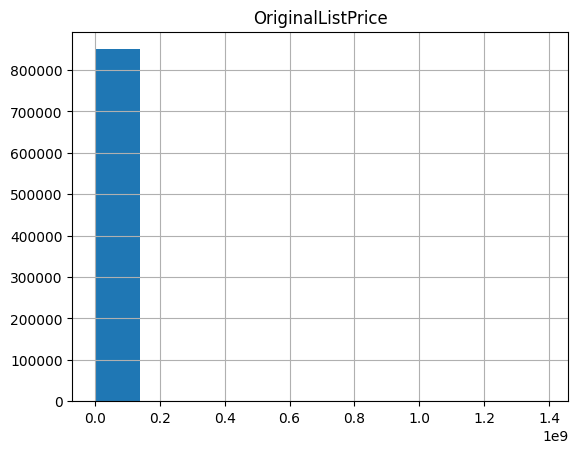

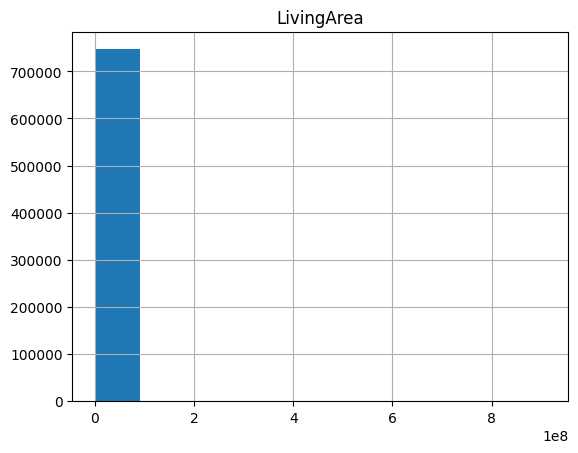

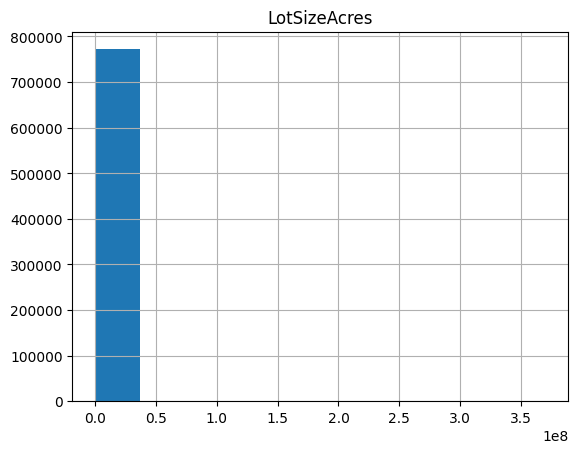

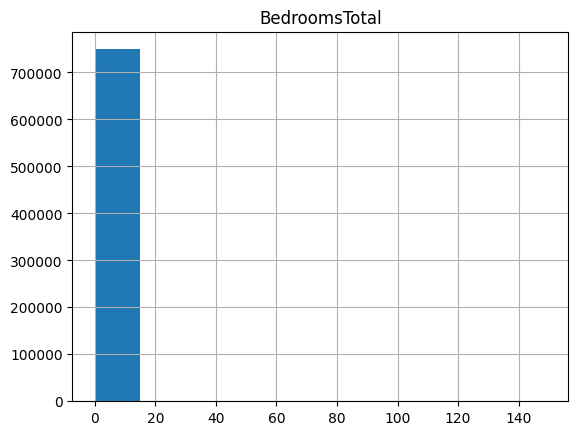

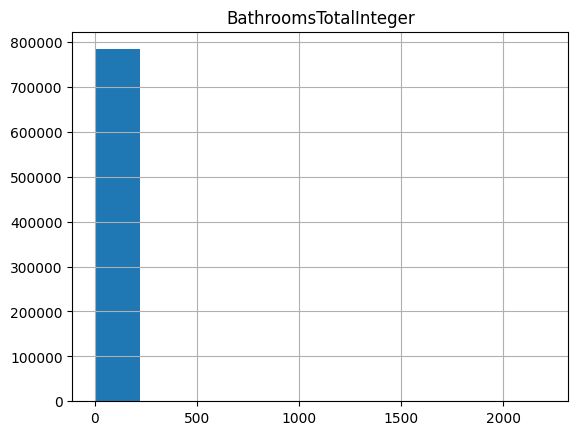

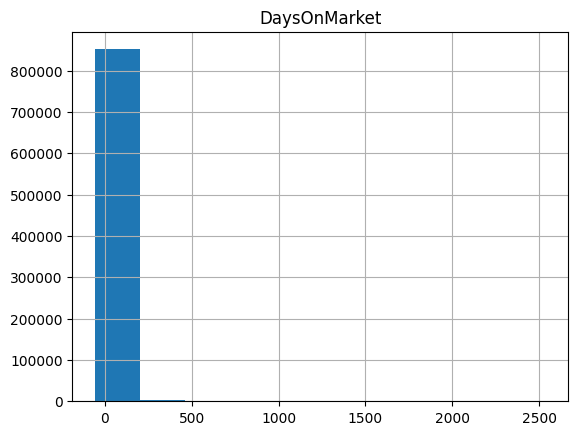

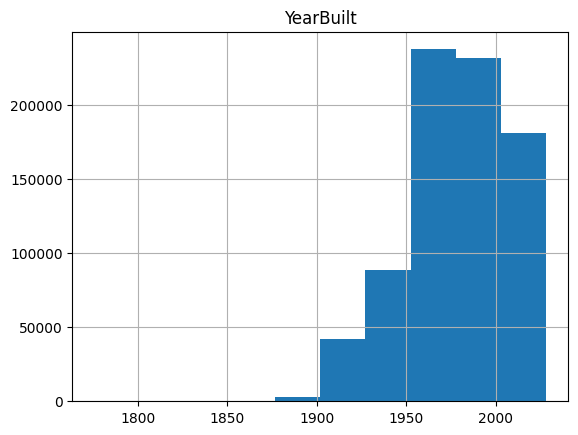

In [18]:
for col in cols:
    df_listing[[col]].hist()

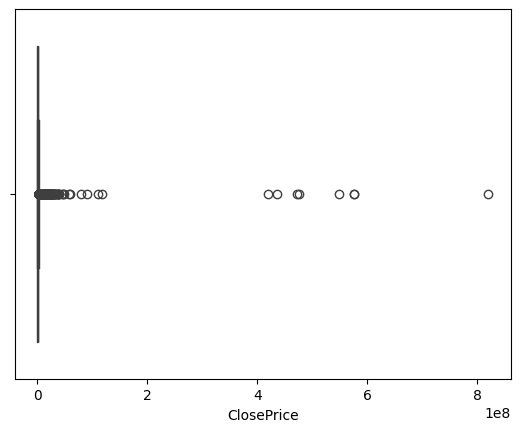

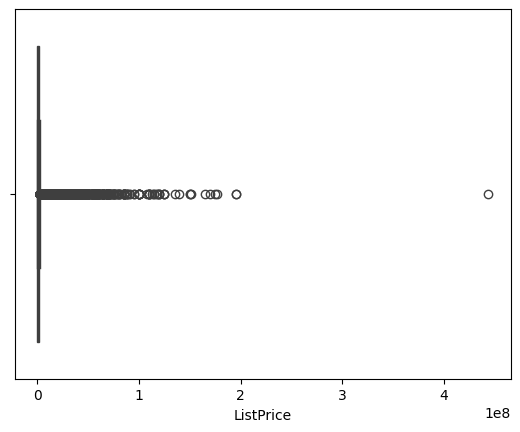

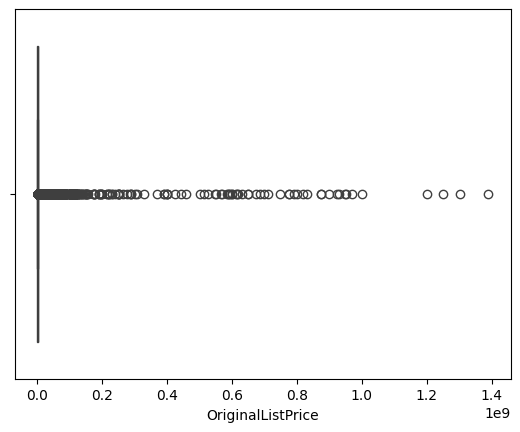

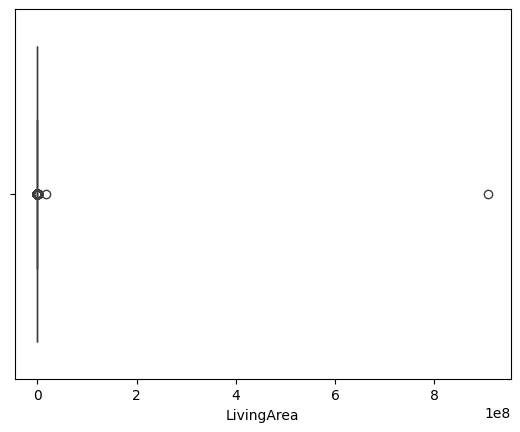

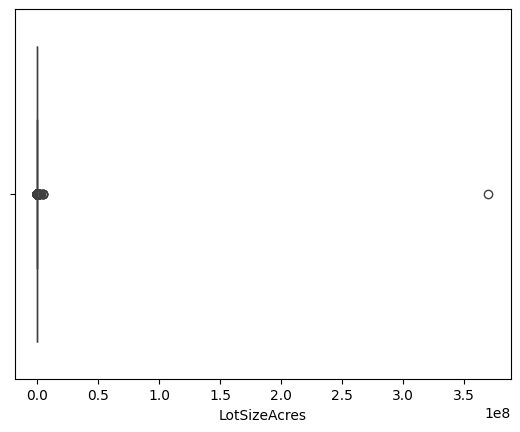

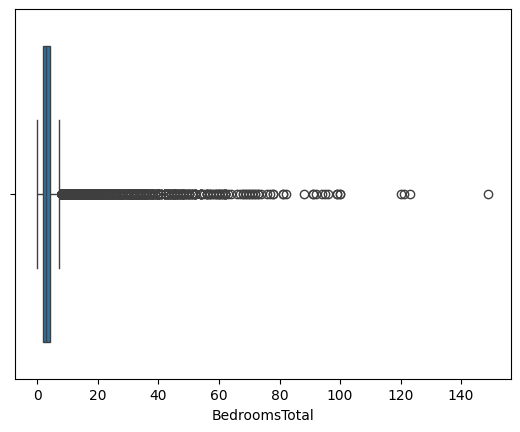

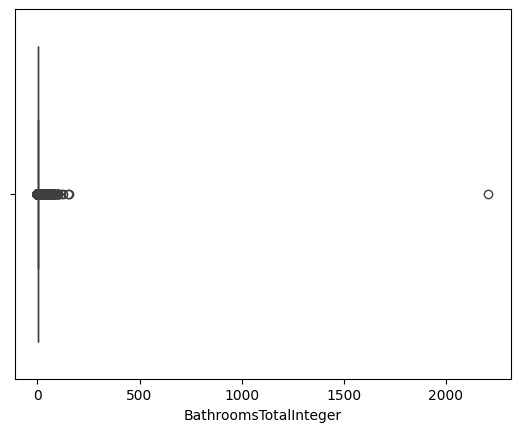

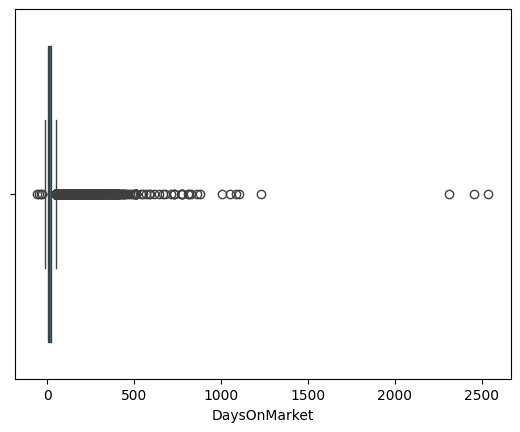

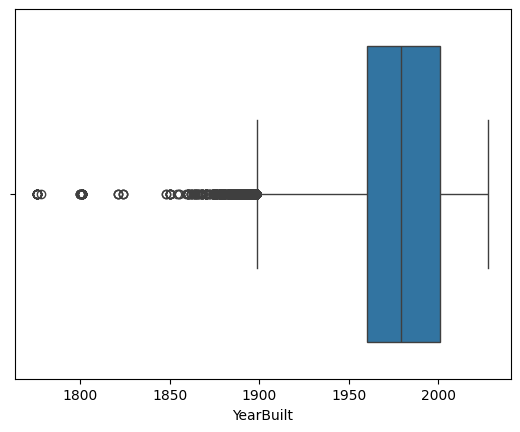

In [19]:
for col in cols:
    sns.boxplot(x=df_listing[col])
    plt.show()

In [20]:
for col in cols:
    print(f"\nColumn: {col}")
    percentiles = df_listing[col].describe(
        percentiles=[0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
    )
    print(percentiles)


Column: ClosePrice
count    2.330590e+05
mean     7.814101e+05
std      3.457756e+06
min      0.000000e+00
10%      3.000000e+03
20%      4.150000e+03
30%      7.500000e+03
40%      3.750000e+05
50%      5.655000e+05
60%      7.290000e+05
70%      9.000000e+05
80%      1.200000e+06
90%      1.730000e+06
max      8.200000e+08
Name: ClosePrice, dtype: float64

Column: ListPrice
count    8.516190e+05
mean     9.842293e+05
std      2.167942e+06
min      0.000000e+00
10%      3.700000e+03
20%      1.000000e+04
30%      2.750000e+05
40%      4.888880e+05
50%      6.350000e+05
60%      7.899000e+05
70%      9.817818e+05
80%      1.329000e+06
90%      1.999000e+06
max      4.436503e+08
Name: ListPrice, dtype: float64

Column: OriginalListPrice
count    8.504440e+05
mean     1.051204e+06
std      6.389884e+06
min      0.000000e+00
10%      3.750000e+03
20%      1.045000e+04
30%      2.790000e+05
40%      4.900000e+05
50%      6.399000e+05
60%      7.950000e+05
70%      9.890000e+05
80%      1.

In [21]:
df_listing[cols].describe()

,ClosePrice,ListPrice,OriginalListPrice,LivingArea,LotSizeAcres,BedroomsTotal,BathroomsTotalInteger,DaysOnMarket,YearBuilt
count,2.330590e+05,8.516190e+05,8.504440e+05,7.472800e+05,7.721830e+05,750673.000000,783806.000000,853754.000000,784284.000000
mean,7.814101e+05,9.842293e+05,1.051204e+06,3.159316e+03,5.508462e+02,3.132505,2.498287,19.143911,1978.400254
std,3.457756e+06,2.167942e+06,6.389884e+06,1.051825e+06,4.214977e+05,1.689075,3.034440,28.847418,28.041624
min,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000,-58.000000,1776.000000
25%,5.000000e+03,8.500000e+04,8.500000e+04,1.182000e+03,1.205000e-01,2.000000,2.000000,4.000000,1960.000000
50%,5.655000e+05,6.350000e+05,6.399000e+05,1.601000e+03,1.722000e-01,3.000000,2.000000,10.000000,1979.000000
75%,1.025000e+06,1.150000e+06,1.150000e+06,2.236000e+03,3.846500e-01,4.000000,3.000000,22.000000,2001.000000
max,8.200000e+08,4.436503e+08,1.390000e+09,9.090909e+08,3.702600e+08,149.000000,2208.000000,2539.000000,2028.000000


##### *Sold*

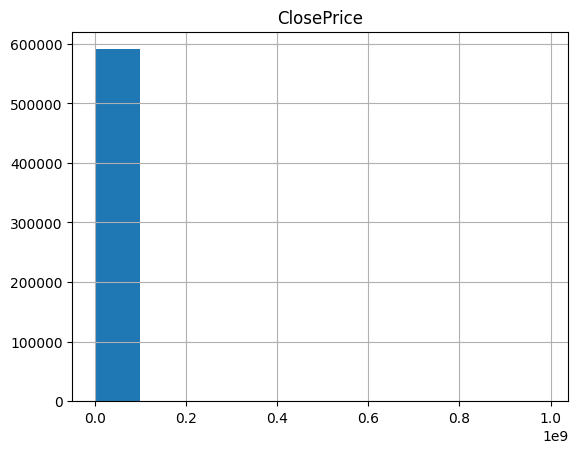

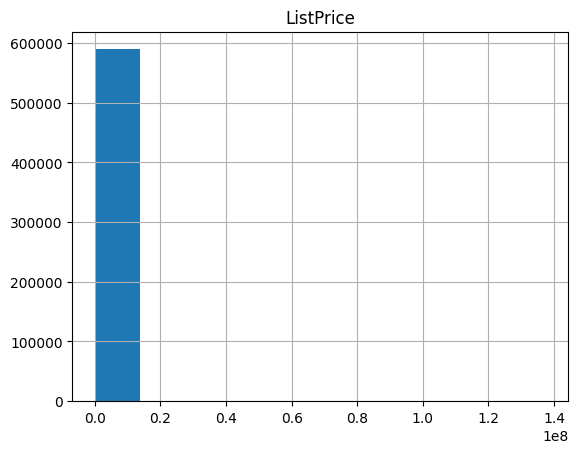

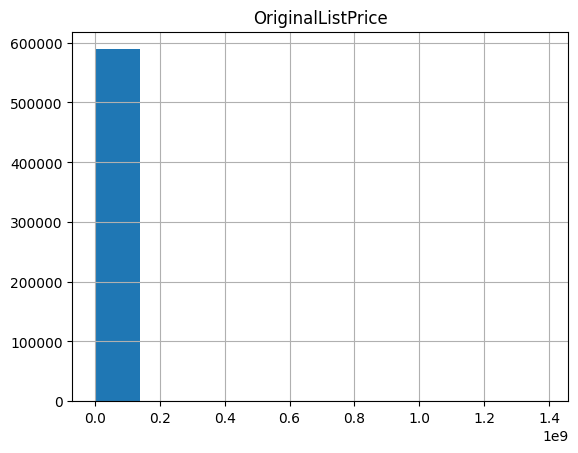

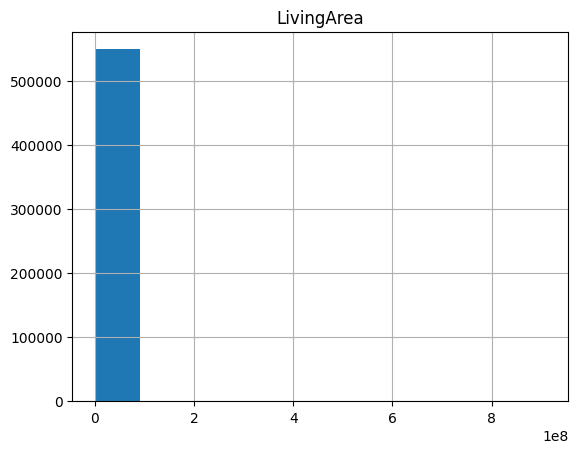

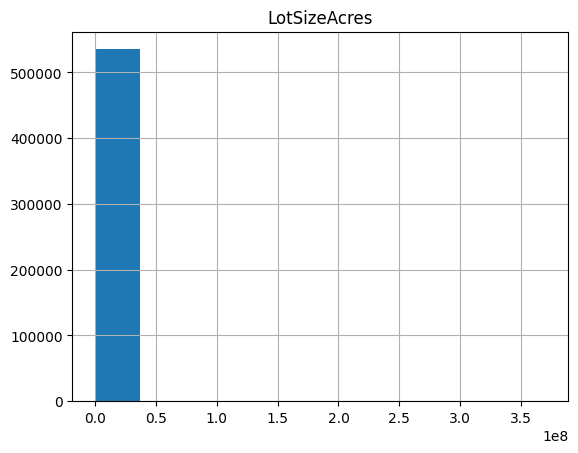

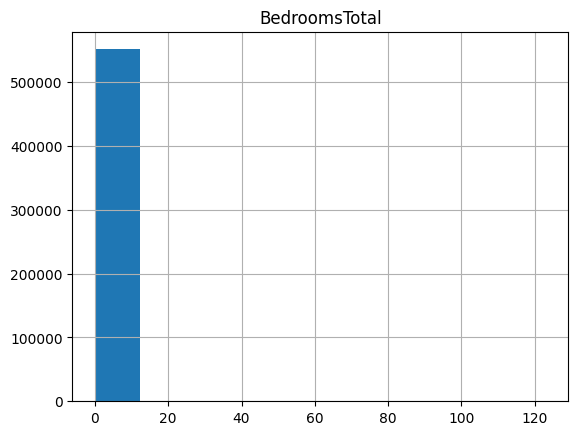

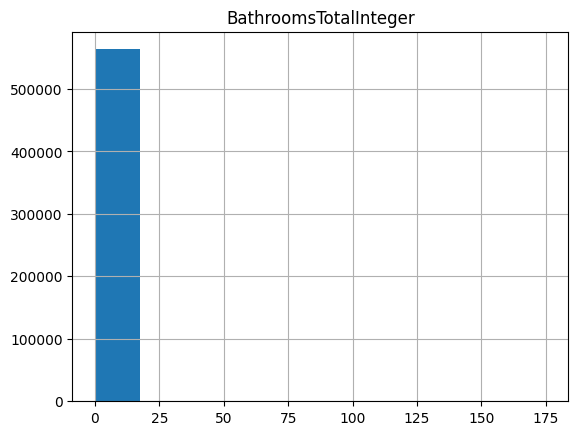

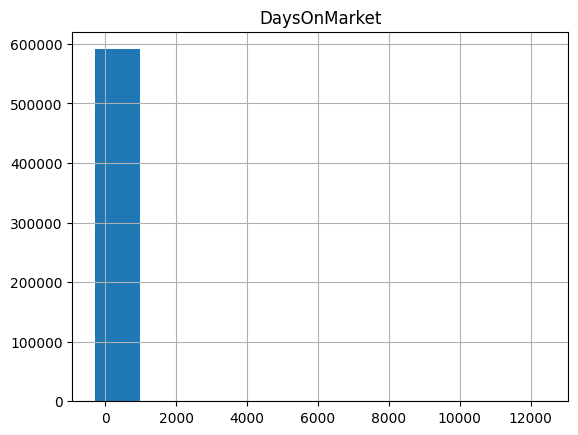

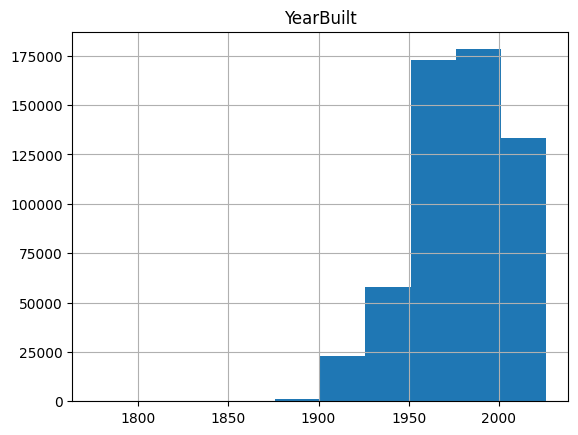

In [22]:
for col in cols:
    df_sold[[col]].hist()

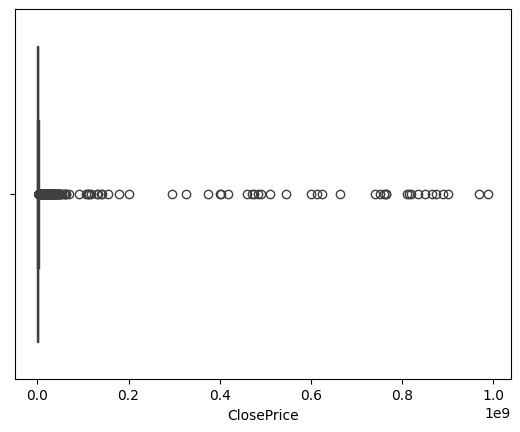

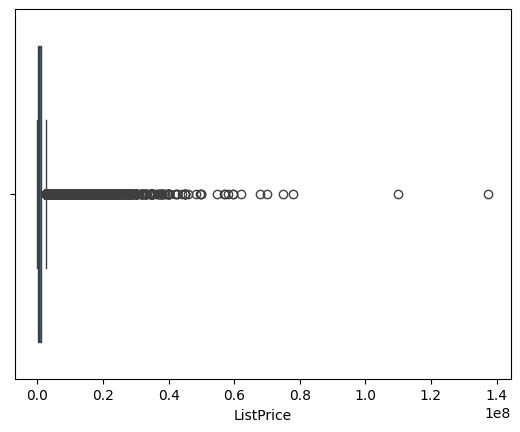

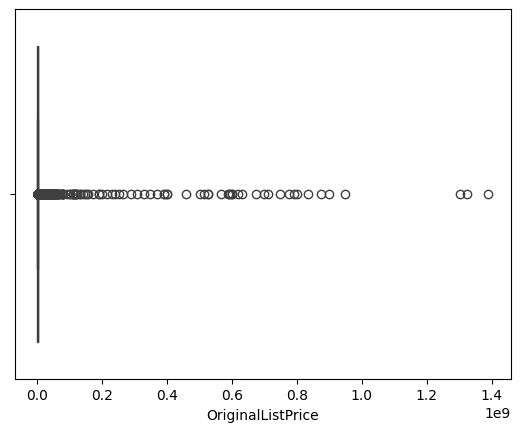

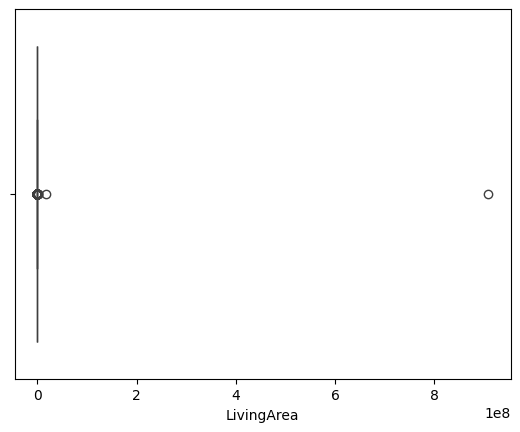

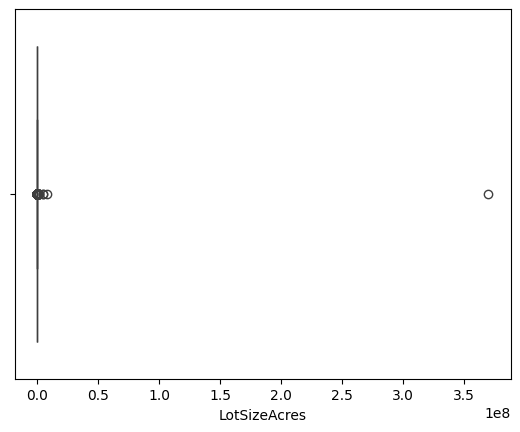

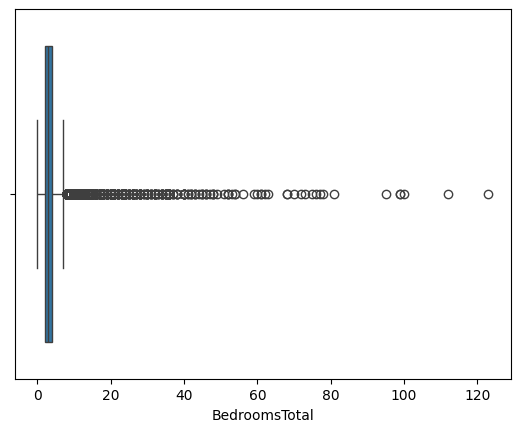

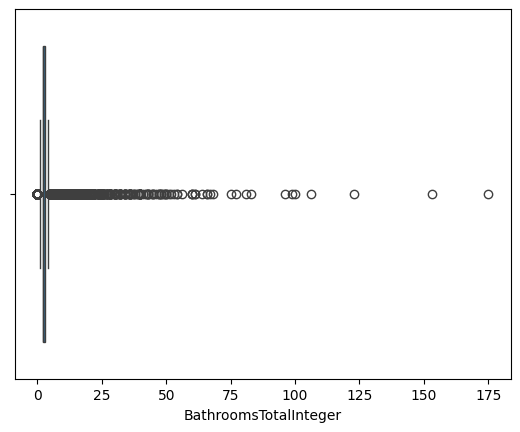

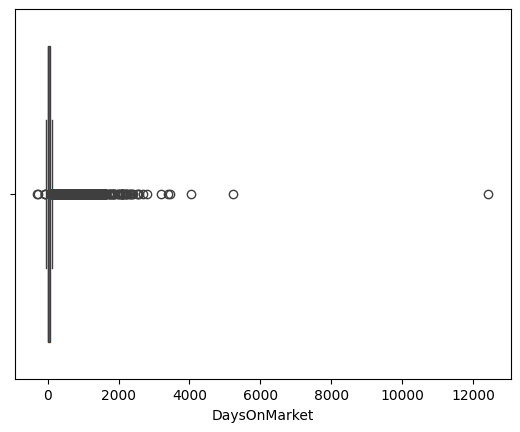

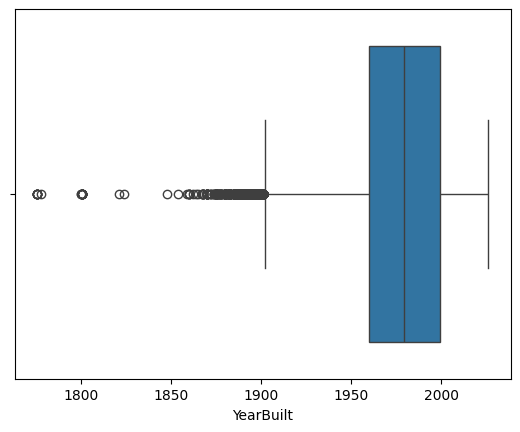

In [23]:
for col in cols:
    sns.boxplot(x=df_sold[col])
    plt.show()

In [24]:
for col in cols:
    print(f"\nColumn: {col}")
    percentiles = df_sold[col].describe(
        percentiles=[0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
    )
    print(percentiles)


Column: ClosePrice
count    5.911080e+05
mean     8.745653e+05
std      5.275319e+06
min      0.000000e+00
10%      3.495000e+03
20%      6.400000e+03
30%      2.850000e+05
40%      4.899972e+05
50%      6.299000e+05
60%      7.684200e+05
70%      9.300000e+05
80%      1.250000e+06
90%      1.782000e+06
max      9.895000e+08
Name: ClosePrice, dtype: float64

Column: ListPrice
count    5.902050e+05
mean     8.400098e+05
std      1.275660e+06
min      0.000000e+00
10%      3.500000e+03
20%      6.500000e+03
30%      2.990000e+05
40%      4.950000e+05
50%      6.299000e+05
60%      7.690000e+05
70%      9.290000e+05
80%      1.239000e+06
90%      1.780000e+06
max      1.375000e+08
Name: ListPrice, dtype: float64

Column: OriginalListPrice
count    5.894040e+05
mean     9.061188e+05
std      5.745172e+06
min      0.000000e+00
10%      3.500000e+03
20%      6.500000e+03
30%      2.999000e+05
40%      4.990000e+05
50%      6.399900e+05
60%      7.780000e+05
70%      9.490000e+05
80%      1.

#### Suggested Intern Questions

Use EDA to answer these questions about your dataset before moving to cleaning:
- What is the Residential vs. other property type share?
- What are the median and average close prices? 
- What does the Days on Market distribution look like?
- What percentage of homes sold above vs. below list price? 
- Are there any apparent date consistency issues (e.g., close date before listing date)?
- Which counties have the highest median prices? 

##### **What is the Residential vs. other property type share (I will be looking at close price)?**

##### *Listing*

In [25]:
df_listing.columns

Index(['OriginalListPrice', 'ListingKey', 'ListAgentEmail', 'CloseDate',
       'ClosePrice', 'ListAgentFirstName', 'ListAgentLastName', 'Latitude',
       'Longitude', 'UnparsedAddress', 'PropertyType', 'LivingArea',
       'ListPrice', 'DaysOnMarket', 'ListOfficeName', 'BuyerOfficeName',
       'CoListOfficeName', 'ListAgentFullName', 'CoListAgentFirstName',
       'CoListAgentLastName', 'BuyerAgentMlsId', 'BuyerAgentFirstName',
       'BuyerAgentLastName', 'FireplacesTotal', 'AssociationFeeFrequency',
       'AboveGradeFinishedArea', 'ListingKeyNumeric', 'MLSAreaMajor',
       'TaxAnnualAmount', 'CountyOrParish', 'PropertyType.1', 'MlsStatus',
       'ElementarySchool', 'ListAgentFirstName.1', 'AttachedGarageYN',
       'ParkingTotal', 'BuilderName', 'PropertySubType', 'LotSizeAcres',
       'SubdivisionName', 'BuyerOfficeAOR', 'YearBuilt', 'DaysOnMarket.1',
       'BuyerAgencyCompensationType', 'StreetNumberNumeric', 'LivingArea.1',
       'ListingId', 'BathroomsTotalInteger', 'Cit

In [26]:
# Again, here is the distribution of each property type 
dist_property = (df_listing['PropertyType'].value_counts() / len(df_listing)) * 100
dist_property

PropertyType
Residential            63.318005
ResidentialLease       20.897120
Land                    6.600848
ResidentialIncome       3.711022
ManufacturedInPark      2.873896
CommercialSale          1.372644
CommercialLease         0.906467
BusinessOpportunity     0.319999
Name: count, dtype: float64

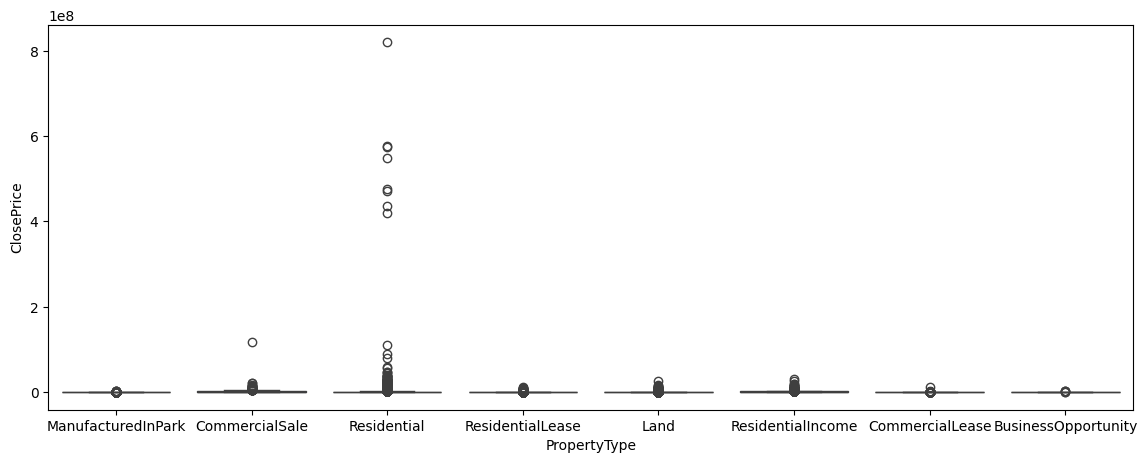

In [27]:
plt.figure(figsize=(14, 5))
sns.boxplot(x='PropertyType', y='ClosePrice', data=df_listing)
plt.show()

Decreasing the range on y-axis (decreasing the listprice)

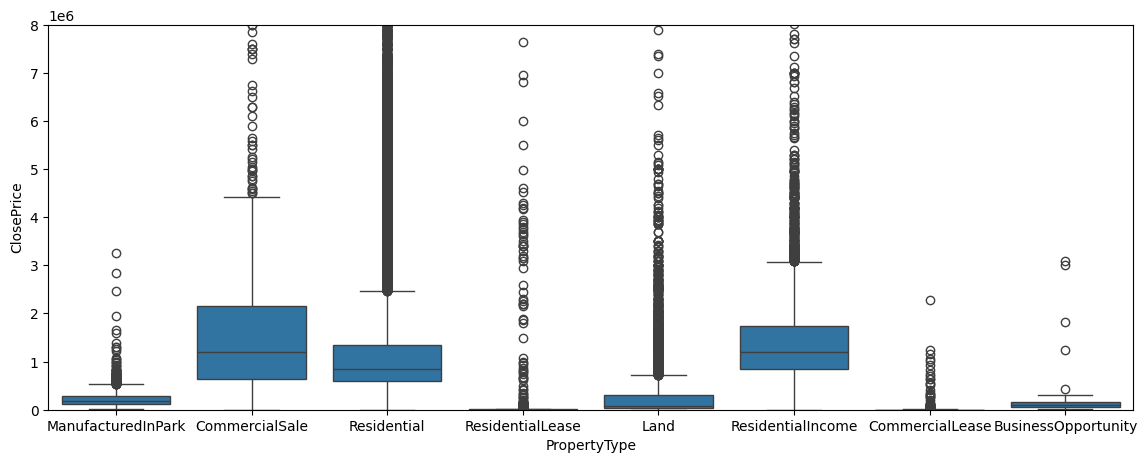

In [28]:
plt.figure(figsize=(14, 5))
sns.boxplot(x='PropertyType', y='ClosePrice', data=df_listing)
plt.ylim([0, 0.8e7])
plt.show()

Properties categorized as "Commercial Sale" (exclusively for business purposes) exhibit a higher median close price and IQR (price variance) than other properities. 

##### *Sold*

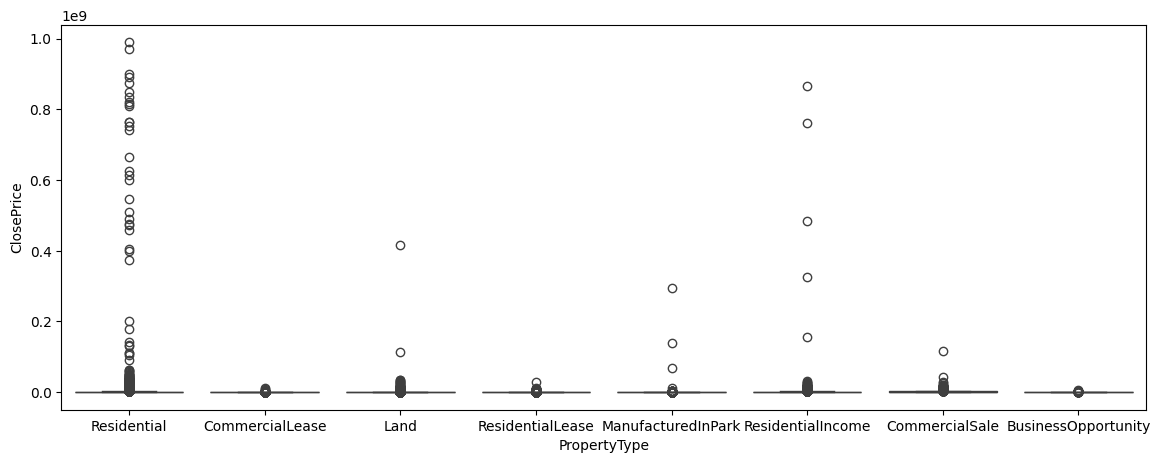

In [29]:
plt.figure(figsize=(14, 5))
sns.boxplot(x='PropertyType', y='ClosePrice', data=df_sold)
plt.show()

Decreasing the y-axis for better analysis

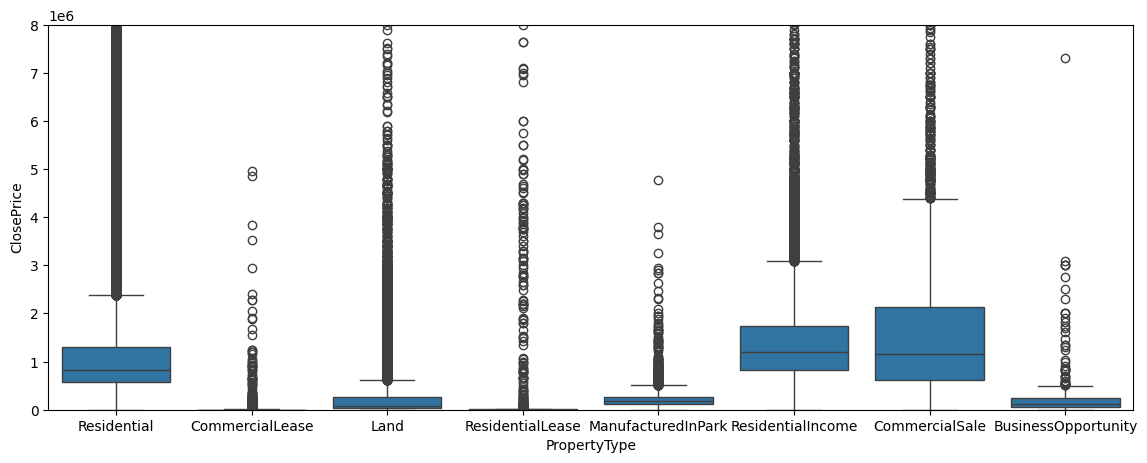

In [30]:
plt.figure(figsize=(14, 5))
sns.boxplot(x='PropertyType', y='ClosePrice', data=df_sold)
plt.ylim([0, 0.8e7])
plt.show()

Similar as listings, which makes sense because the listings and sold properties are the same properties, just sold properties may not include all the listings. Just the median of properties of 'Residential Income' is a bit bigger.

##### **What are the median and average close prices?**

##### *Listing*

In [31]:
df_listing['ClosePrice'].median()

np.float64(565500.0)

In [32]:
df_listing['ClosePrice'].mean().round(2)

np.float64(781410.12)

In [33]:
df_listing['ClosePrice'].describe()

count    2.330590e+05
mean     7.814101e+05
std      3.457756e+06
min      0.000000e+00
25%      5.000000e+03
50%      5.655000e+05
75%      1.025000e+06
max      8.200000e+08
Name: ClosePrice, dtype: float64

Looking at the average close price, they are lower than the average close price of sold properties, which could be due to properties are frequently closing above their initial list prices. This can reflect the real estate behavior of these properties being competitively sought after and potentially some agent strategies to increase the initial listing price to close at a higher price. Looking at how the mean is greater than the median, it indicates that there are a few extreme values (very pricy properties) and a majority of properties are within a common bracket of close prices. 

##### *Sold*

In [34]:
df_sold['ClosePrice'].median()

np.float64(629900.0)

In [35]:
df_sold['ClosePrice'].mean().round(2)

np.float64(874565.3)

More expensive properties are being sold on average. Since the median close price is less than the average close price, we can acknowledge that the data is skewed towards the right. In conceptual sense, this means that there are a few extreme values towards the higher-end close prices and the majority of the close price are commonly in the lower close price. 

##### **What does the Days on Market distribution look like?**

##### *Listing*

<Axes: >

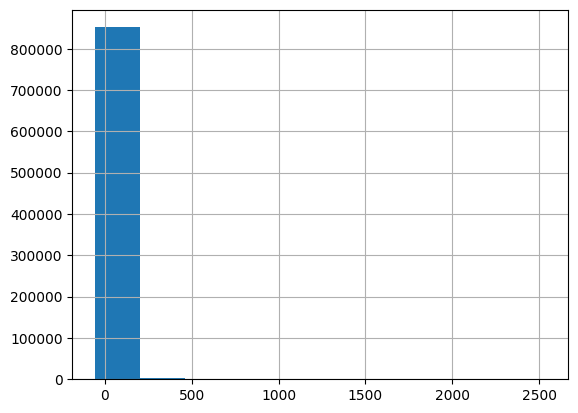

In [36]:
df_listing['DaysOnMarket'].hist()

In [37]:
df_listing['DaysOnMarket'].describe()

count    853754.000000
mean         19.143911
std          28.847418
min         -58.000000
25%           4.000000
50%          10.000000
75%          22.000000
max        2539.000000
Name: DaysOnMarket, dtype: float64

(0.0, 100.0)

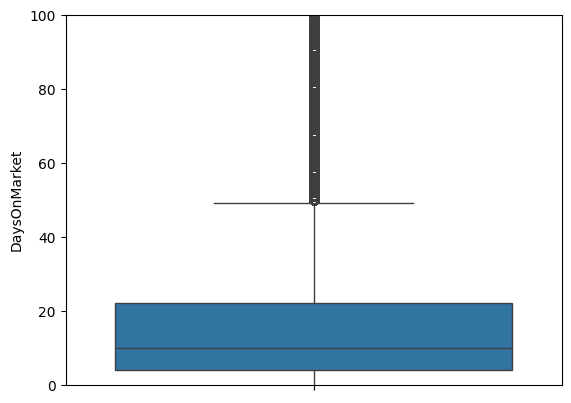

In [38]:
sns.boxplot(df_listing['DaysOnMarket'])
plt.ylim([0, 100])

The data on the 'Days on Market' is overall heavily skewed towards the right. There are a few outliers which indicate a few properties were on the market for greater number of days, but a common number of them were on the market for 4-22 days. 

##### *Sold*

In [39]:
df_sold['DaysOnMarket'].describe()

count    591115.000000
mean         43.284872
std          69.834015
min        -288.000000
25%           9.000000
50%          22.000000
75%          54.000000
max       12430.000000
Name: DaysOnMarket, dtype: float64

(0.0, 125.0)

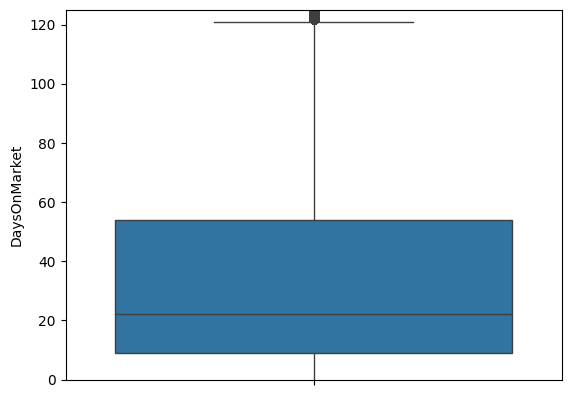

In [40]:
sns.boxplot(df_sold['DaysOnMarket'])
plt.ylim([0, 125])

Similarly, the data is skewed towards the right. The common range is from 9-54 days, which may mean that before the property was successfully sold/closed, it was sitting on the market within that range of time. 

##### **What percentage of homes sold above vs. below list price?**

In [41]:
df_percent_sold = df_sold

In [42]:
count_above = len(df_sold[df_sold['ClosePrice'] > df_sold['ListPrice']])
count_above

181396

In [43]:
count_below = len(df_sold[df_sold['ClosePrice'] < df_sold['ListPrice']])
count_below

227109

In [44]:
total_properties = len(df_sold)
total_properties

591115

In [45]:
percent_above = round((count_above / total_properties) * 100, 2)
percent_above

30.69

In [46]:
percent_below = round((count_below / total_properties) * 100, 2)
percent_below

38.42

##### **Are there any apparent date consistency issues (e.g., close date before listing date)?**

##### *Listing*

In [47]:
date_cols = ['CloseDate', 'ContractStatusChangeDate', 'PurchaseContractDate', 'ListingContractDate']
for col in date_cols:
    df_listing[col] = pd.to_datetime(df_listing[col])

# Check 1: Sold before it was even listed?
df_listing['Issue_Sold_Before_Listed'] = df_listing['CloseDate'] < df_listing['ListingContractDate']

# Check 2: Closed before the contract was signed?
df_listing['Issue_Closed_Before_Contract'] = df_listing['CloseDate'] < df_listing['PurchaseContractDate']

# Check 3: Contract signed before it was listed?
df_listing['Issue_Contract_Before_Listing'] = df_listing['PurchaseContractDate'] < df_listing['ListingContractDate']

In [48]:
df_listing['Issue_Sold_Before_Listed'].value_counts()

Issue_Sold_Before_Listed
False    853619
True        135
Name: count, dtype: int64

In [49]:
df_listing['Issue_Closed_Before_Contract'].value_counts()

Issue_Closed_Before_Contract
False    853404
True        350
Name: count, dtype: int64

In [50]:
df_listing['Issue_Contract_Before_Listing'].value_counts()

Issue_Contract_Before_Listing
False    853357
True        397
Name: count, dtype: int64

Looking at these date issues, we may have to remove these rows as data may have been inaccurately inputted. 

##### *Sold*

In [51]:
for col in date_cols:
    df_sold[col] = pd.to_datetime(df_sold[col])

# Check 1: Sold before it was even listed?
df_sold['Issue_Sold_Before_Listed'] = df_sold['CloseDate'] < df_sold['ListingContractDate']

# Check 2: Closed before the contract was signed?
df_sold['Issue_Closed_Before_Contract'] = df_sold['CloseDate'] < df_sold['PurchaseContractDate']

# Check 3: Contract signed before it was listed?
df_sold['Issue_Contract_Before_Listing'] = df_sold['PurchaseContractDate'] < df_sold['ListingContractDate']

In [52]:
df_sold['Issue_Sold_Before_Listed'].value_counts()

Issue_Sold_Before_Listed
False    591008
True        107
Name: count, dtype: int64

In [53]:
df_sold['Issue_Closed_Before_Contract'].value_counts()

Issue_Closed_Before_Contract
False    590760
True        355
Name: count, dtype: int64

In [54]:
df_sold['Issue_Contract_Before_Listing'].value_counts()

Issue_Contract_Before_Listing
False    590739
True        376
Name: count, dtype: int64

Same goes here

##### **Which counties have the highest median prices?**

##### *Listing*

In [55]:
df_listing['CountyOrParish'].value_counts()

CountyOrParish
Los Angeles       266138
Riverside         110307
Orange             93486
San Diego          90298
San Bernardino     83204
                   ...  
Lassen                54
Del Norte             18
Sierra                 5
Alpine                 5
Clark                  4
Name: count, Length: 63, dtype: int64

In [56]:
county_stats = df_listing.groupby('CountyOrParish')['ClosePrice'].median()

In [57]:
highest_median_county = county_stats.sort_values(ascending=False)

In [58]:
highest_median_county.head()

CountyOrParish
Santa Clara      1525000.0
San Mateo        1450000.0
Marin            1160000.0
San Francisco    1125000.0
Alameda          1089000.0
Name: ClosePrice, dtype: float64

##### *Sold*

In [59]:
county_stats = df_sold.groupby('CountyOrParish')['ClosePrice'].median()

In [60]:
highest_median_county = county_stats.sort_values(ascending=False)

In [61]:
highest_median_county.head()

CountyOrParish
Santa Clara      1490101.0
San Mateo        1450000.0
Alpine           1100000.0
San Francisco    1090000.0
Alameda          1050000.0
Name: ClosePrice, dtype: float64

The ranking of Santa Clara, San Mateo, San Francisco, and Alameda are the same for listed and sold properties. 